In [5]:
# Cell 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

In [6]:
# Cell 2: Load Unified Pipeline Data
project_root = Path().resolve().parents[0]
results_path = project_root / "experiments" / "unified_pipeline_results.csv"

if results_path.exists():
    df_unified = pd.read_csv(results_path)
    display(df_unified.head())
else:
    print(f"File not found: {results_path}")

,Scenario,Prob_NIDS,Prob_PE,Unified_Score,Pred_NIDS,Pred_PE,Pred_Unified,True_Threat
0,NIDS:0|PE:0,0.489316,0.291692,0.638279,0,0,1,0
1,NIDS:0|PE:0,0.650859,0.029943,0.661314,1,0,1,0
2,NIDS:0|PE:0,0.584120,0.028898,0.596138,1,0,1,0
3,NIDS:0|PE:0,0.323533,0.050191,0.357486,0,0,0,0
4,NIDS:0|PE:0,0.222481,0.085616,0.289050,0,0,0,0


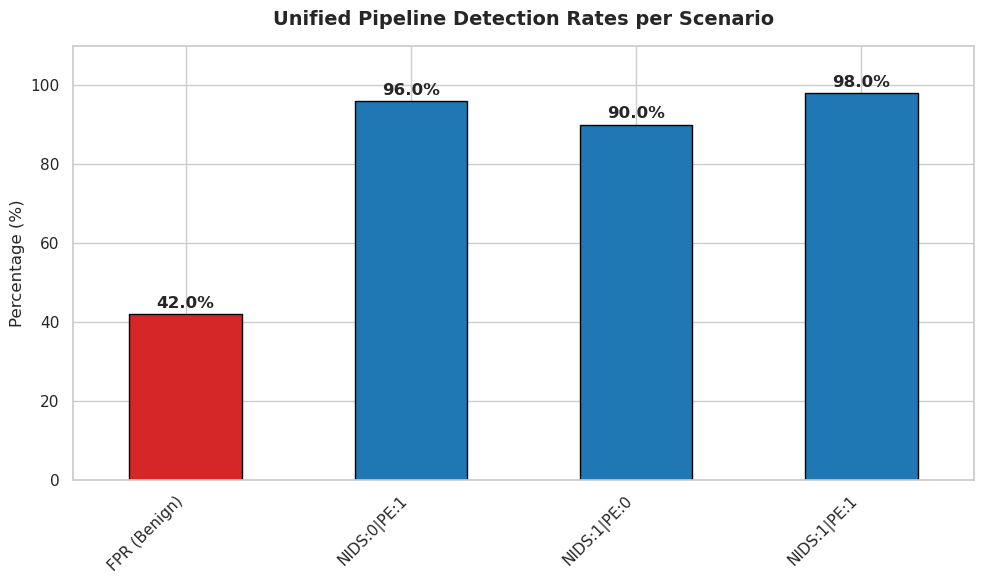

In [7]:
# Cell 3: Plot Detection Rates by Scenario (Bar Chart)
if results_path.exists():
    # Calculate detection rate for malicious scenarios (True_Threat == 1)
    malicious_df = df_unified[df_unified['True_Threat'] == 1]
    detection_rates = malicious_df.groupby('Scenario')['Pred_Unified'].mean() * 100
    
    # Calculate False Positive Rate for benign scenario
    benign_df = df_unified[df_unified['True_Threat'] == 0]
    fpr = benign_df['Pred_Unified'].mean() * 100
    
    # Combine for plotting
    plot_data = pd.Series({"FPR (Benign)": fpr})
    plot_data = pd.concat([plot_data, detection_rates])
    
    plt.figure(figsize=(10, 6))
    colors = ['tab:red'] + ['tab:blue'] * len(detection_rates)
    
    ax = plot_data.plot(kind='bar', color=colors, edgecolor='black')
    
    plt.title("Unified Pipeline Detection Rates per Scenario", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Percentage (%)", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 110)
    
    # Add percentage labels on top of bars
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), 
                    textcoords='offset points', fontweight='bold')
        
    plt.tight_layout()
    plt.show()


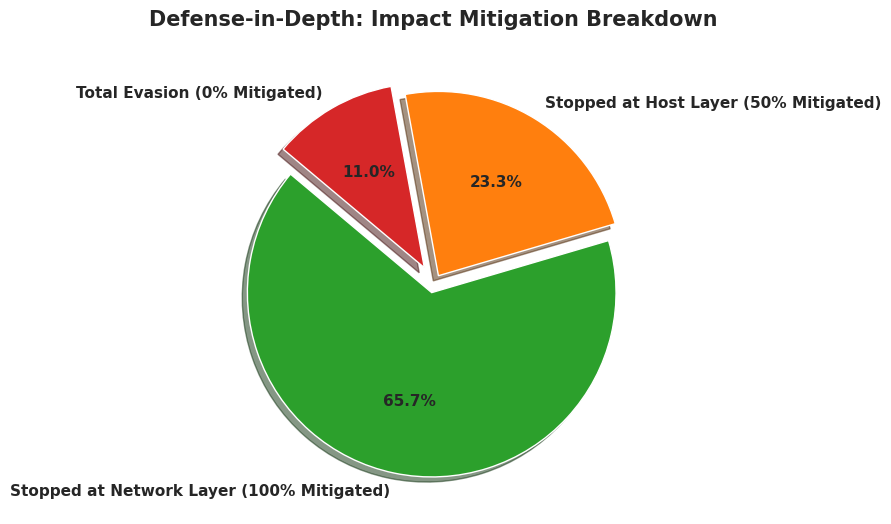

In [8]:
# Cell 4: Impact Mitigation Distribution (Pie Chart)
if results_path.exists():
    # Only analyze true threats for mitigation
    threats = df_unified[df_unified['True_Threat'] == 1]
    
    caught_by_nids = len(threats[threats['Pred_NIDS'] == 1])
    missed_by_nids = threats[threats['Pred_NIDS'] == 0]
    caught_by_pe = len(missed_by_nids[missed_by_nids['Pred_PE'] == 1])
    missed_by_both = len(missed_by_nids[missed_by_nids['Pred_PE'] == 0])
    
    labels = [
        'Stopped at Network Layer (100% Mitigated)', 
        'Stopped at Host Layer (50% Mitigated)', 
        'Total Evasion (0% Mitigated)'
    ]
    sizes = [caught_by_nids, caught_by_pe, missed_by_both]
    colors = ['#2ca02c', '#ff7f0e', '#d62728']
    explode = (0.05, 0.05, 0.1)  # highlight the missed threats
    
    plt.figure(figsize=(8, 8))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, 
            autopct='%1.1f%%', shadow=True, startangle=140, 
            textprops={'fontsize': 11, 'fontweight': 'bold'})
    
    plt.title("Defense-in-Depth: Impact Mitigation Breakdown", fontsize=15, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()